In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)

df = pd.DataFrame({
    "Student_ID": range(1, 21),
    "Name": [f"Student_{i}" for i in range(1, 21)],
    "Age": np.random.randint(18, 25, 20),
    "Math": np.random.randint(50, 100, 20),
    "Science": np.random.randint(55, 100, 20),
    "Department": np.random.choice(["CSE", "ISE", "ECE"], 20)
})

df.loc[3, "Math"] = np.nan
df.loc[7, "Science"] = np.nan

df

,Student_ID,Name,Age,Math,Science,Department
0,1,Student_1,24,79.0,75.0,ISE
1,2,Student_2,21,87.0,63.0,ISE
2,3,Student_3,22,51.0,93.0,ISE
3,4,Student_4,24,NaN,72.0,ISE
4,5,Student_5,20,82.0,58.0,ISE
5,6,Student_6,22,61.0,79.0,ISE
6,7,Student_7,22,71.0,68.0,CSE
7,8,Student_8,24,93.0,NaN,ECE
8,9,Student_9,19,74.0,80.0,ISE
9,10,Student_10,20,98.0,56.0,ISE


In [3]:
print("Shape:")
print(df.shape)

print("\nInformation:")
df.info()

print("\nDescription:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

Shape:
(20, 6)

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Student_ID  20 non-null     int64  
 1   Name        20 non-null     object 
 2   Age         20 non-null     int64  
 3   Math        19 non-null     float64
 4   Science     19 non-null     float64
 5   Department  20 non-null     object 
dtypes: float64(2), int64(2), object(2)
memory usage: 1.1+ KB

Description:
       Student_ID        Age       Math    Science
count    20.00000  20.000000  19.000000  19.000000
mean     10.50000  21.500000  76.421053  75.421053
std       5.91608   1.670172  15.038158  12.919906
min       1.00000  19.000000  51.000000  56.000000
25%       5.75000  20.000000  64.500000  65.500000
50%      10.50000  21.500000  77.000000  74.000000
75%      15.25000  22.250000  89.000000  85.500000
max      20.00000  24.000000  98.000000  98.000000

Missi

In [5]:
df["Math"] = df["Math"].fillna(df["Math"].mean())
df["Science"] = df["Science"].fillna(df["Science"].mean())

print(df.isnull().sum())


Student_ID    0
Name          0
Age           0
Math          0
Science       0
Department    0
dtype: int64


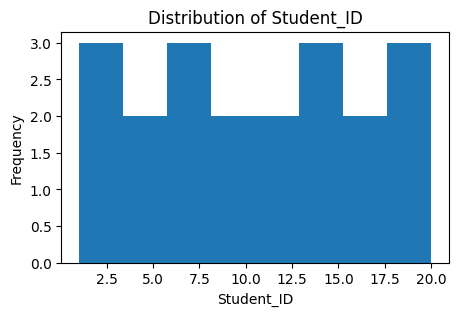

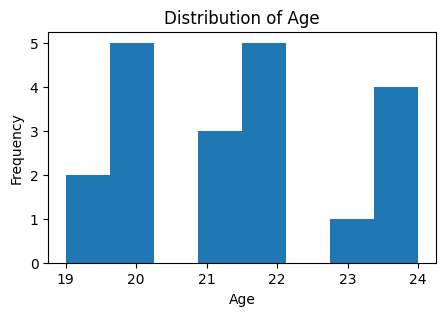

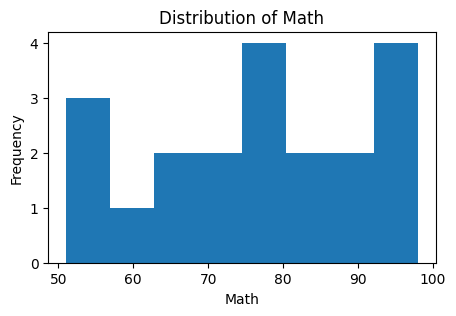

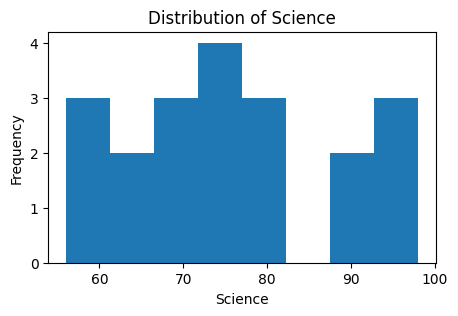

In [6]:
numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    plt.figure(figsize=(5,3))
    plt.hist(df[column], bins=8)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

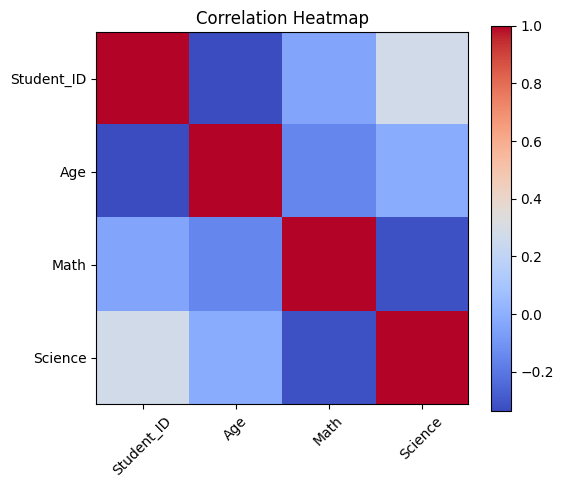

In [7]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(6,5))
plt.imshow(corr, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.show()

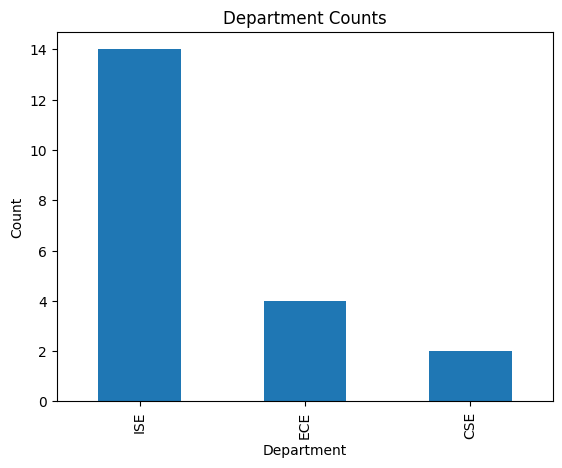

In [8]:
df["Department"].value_counts().plot(kind="bar")

plt.title("Department Counts")
plt.xlabel("Department")
plt.ylabel("Count")

plt.show()

In [9]:
df.to_csv("EDA_Cleaned_Data.csv", index=False)

print("Dataset saved successfully.")

Dataset saved successfully.
